# <span style="color:teal"> Lezione 7</span>
## <span style="color:turquoise"> Esercizio 7.1 </span>

In questo esercizio è stato chiesto di implementare le correzioni di coda all'energia potenziale $U$ e alla pressione $P$, causate dal troncamento del potenziale di Lennard-Jones a una distanza finita $r_c$. Queste correzioni sono state implementate con le seguenti formule, dove con $^*$ sono indicate le grandezze in unità LJ:
$$ \frac{\langle U \,\rangle_{tail}}{N} 
=  8\pi \rho\, \epsilon \left[ \frac{1}{9}\left(\frac{\sigma}{r_c}\right)^9 - \frac{1}{3}\left(\frac{\sigma}{r_c}\right)^3 \right] 
= 8\pi\rho^*\left[\frac{1}{9\,r_c^{*9}} - \frac{1}{3\,r_c^{*3}}\right] $$

$$ \frac{\langle P\, \rangle_{tail}}{N} 
= 32\pi \rho \left[ \frac{1}{9}\left(\frac{\sigma}{r_c}\right)^9 - \frac{1}{6}\left(\frac{\sigma}{r_c}\right)^3 \right] 
= 32\pi\rho^*\left[\frac{1}{9\,r_c^{*9}} - \frac{1}{6\,r_c^{*3}}\right] $$

## <span style="color:turquoise"> Esercizio 7.2 </span>
In questo esercizio è stato chiesto di analizzare un sistema di $N=108$ particelle in fase liquida (densità $\rho^\star = 0.8$ e temperatura $T^\star = 1.1$) e di misurare l'energia potenziale per particella $U/N$ sia attraverso una simulazione Monte Carlo (MC) nell'ensemble canonico $(N,V,T)$, sia una simulazione di Dinamica Molecolare (MD) nell'ensemble microcanonico $(N, V, E)$.  
Per entrambe le simulazioni è stato utlizzato un raggio di cut-off del potenziale $r_c^*=2.5$, per MD è stato usato $dt^*=0.001$, mentre per MC è stato usato $dt=0.1$, che in questo caso rappresenta l'ampiezza del passo, per avere un'accettanza di circa $50\%$.  

Gli obiettivi principali dell'esercizio sono:
1. Stimare la funzione di autocorrelazione per l'energia potenziale per particella $U/N$
2. Stimare, tramite data blocking, l'errore statistico del valor medio dell'energia potenziale per particella $\langle U/N \rangle$ al variare della dimensione $L$ dei blocchi

Per entrambe le simulazioni è necessaria una fase di equilibrazione.
- Per MD si osserva che la temperatura diminuisce significativamente, perciò è necessario partire da una configurazione con temperatura maggiore (nel nostro caso si è verificato che la temperatura ottimale corrisponde a $T^*=1.995$), in modo tale che il sistema oscilli attorno alla temperatura desiderata di $T^*=1.1$. Come si può vedere dal grafico sottostante a sinistra, la temperatura si stabilizza rapidamente attorno al valore desiderato.
- Per MC, poichè la temperatura è una costante del sistema, verifichiamo che l'energia interna per particella $U/N$ si assesti a oscillare attorno a un valor medio. Come si può vedere dal grafico sottostante a destra, ciò avviene molto rapidamente.

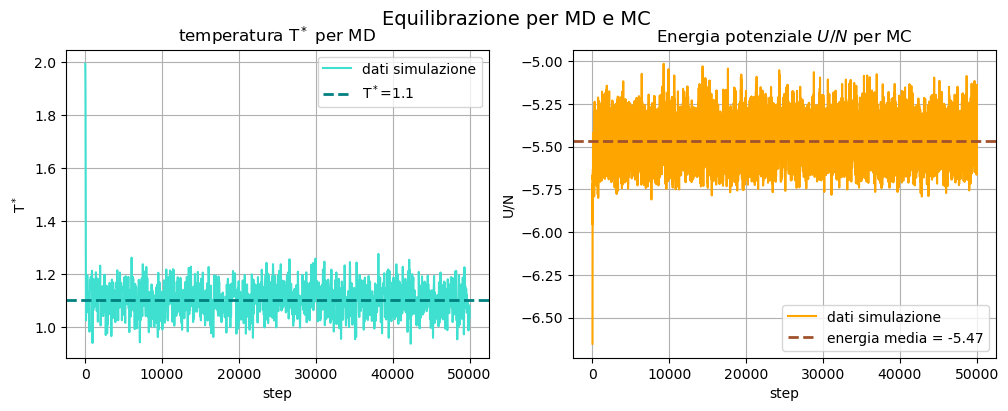

In [1]:
# Equilibrazione MD e MC
import numpy as np
import matplotlib.pyplot as plt

temp_time_MD = np.loadtxt("Esercizio7.1/OUTPUT/equi_temp_MD.dat", comments='#')
penergy_time_MC = np.loadtxt("Esercizio7.1/OUTPUT/equi_pe_MC.dat", comments='#')

n_step = np.linspace(1, len(temp_time_MD), len(temp_time_MD))


en_media = np.mean(penergy_time_MC[100:])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Equilibrazione per MD e MC', fontsize=14)

ax1.plot(n_step,temp_time_MD,color='turquoise', label = 'dati simulazione')
ax1.axhline(y=1.1, color='teal', linestyle='--', linewidth=2, label = "T$^*$=1.1")
ax1.set_xlabel("step")
ax1.set_ylabel("T$^*$")
ax1.set_title("temperatura T$^*$ per MD")
ax1.grid()
ax1.legend()

ax2.plot(n_step,penergy_time_MC,color='orange', label = 'dati simulazione')
ax2.axhline(y=en_media, color='sienna', linestyle='--', linewidth=2, label = f'energia media = {en_media:.3g}')
ax2.set_xlabel("step")
ax2.set_ylabel("U/N")
ax2.set_title("Energia potenziale $U/N$ per MC")
ax2.grid()
ax2.legend()

plt.show()

Per quanto riguarda il primo punto, la funzione di autocorrelazione $A(\tau)$ indica quanto la correlazione originale (lag=0) sopravvive dopo $\tau$ passi; quando l'autocorrelazione rimane stabilmente intorno allo zero, significa che il sistema ha perso memoria del suo passato. Il lag $\tau^*$ a partire dal quale avviene questo, corrisponde al numero di passi necessari affinchè i blocchi siano statisticamente indipendenti l'uno dall'altro.   

La funzione di autocorrelazione normalizzata $A(\tau)$ è stata implementata con la seguente formula, dove $x(t)$ è l'energia interna del sistema al passo t della simulazione, $\bar x$ la sua media temporale e $\sigma^2$ la sua varianza:
$$ A(\tau) = \frac{\langle(x(t)-\bar x)(x(t+\tau)-\bar x) \rangle}{\sigma^2} $$

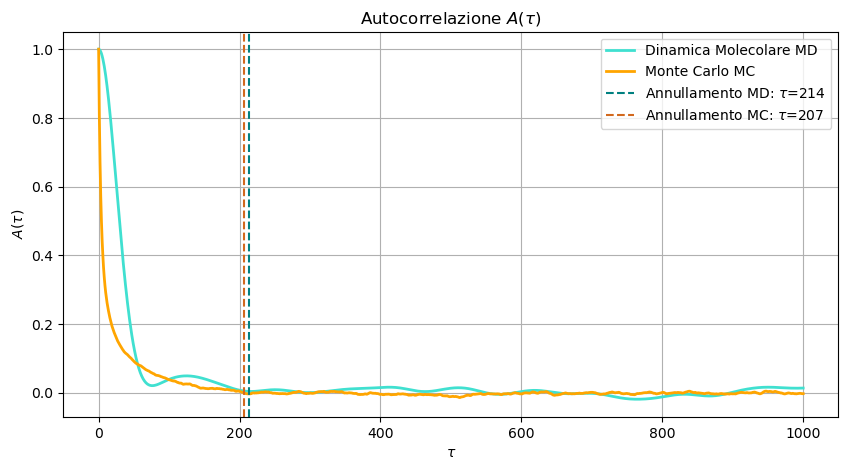

In [2]:
# Calcolo e stampa autocorrelazione

import numpy as np
import matplotlib.pyplot as plt

def CaricaDati(filename):
    pot_energy = np.loadtxt(filename, comments='#')
    return pot_energy


def Autocorrelazione(x, max_lag):
    N=len(x)           # lunghezza di x (n totale di dati)
    mean=np.mean(x)    # calcola la media dei valori di x
    var=np.var(x)      # calcola la varianza dei valori di x

    lags=np.arange(0,max_lag+1)      # crea array dei ritardi
    correlaz=np.zeros(len(lags))     # crea array di tutti 0 della stessa dim di lags

    for i, tau in enumerate(lags):   # i=posiz nell'array e tau=valore del ritardo
        if tau == 0:
            correlaz[i]=1.0          # se tau=0 la correlaz è massima (cioè la serie è identica a se stessa)
        else:
            correlaz[i] = np.mean(         
                (x[:N-tau] - mean)         #   serie originale traslata (da 0 a N-tau) meno la media
                * (x[tau:] - mean)         #   serie spostata di tau passi (da tau a N) meno la media
            ) / var                        #   diviso la varianza per normalizzare tra -1 e 1
    
    return lags, correlaz


def NullAutocorr_MC(C, lag):
    for i in range(1, len(C)): 
        if C[i] == 0:
            return lag[i] 
        if np.sign(C[i]) < 0:
            return lag[i] 

def NullAutocorr_MD(C, lag):
    for i in range(1, len(C)): 
        if C[i] <0.0038:
            return lag[i]
        if np.sign(C[i]) < 0:
            return lag[i] 


# ---------------- inizio main ---------------------------------------------------------------------------------------------------------------

MAX_LAG = 1000

pot_energy_MD = CaricaDati("Esercizio7.1/OUTPUT/actual_pe_MD.dat")
lags_MD, C_MD = Autocorrelazione(pot_energy_MD, MAX_LAG)

pot_energy_MC = CaricaDati("Esercizio7.1/OUTPUT/actual_pe_MC.dat")
lags_MC, C_MC = Autocorrelazione(pot_energy_MC, MAX_LAG)

Lag_null_MD = NullAutocorr_MD(C_MD, lags_MD)
Lag_null_MC = NullAutocorr_MC(C_MC, lags_MC)


plt.figure(figsize=(10, 5))

plt.plot(lags_MD, C_MD, color='turquoise', lw=2, label='Dinamica Molecolare MD')
plt.plot(lags_MC, C_MC, color='orange', lw=2, label='Monte Carlo MC')
plt.axvline(x=Lag_null_MD, color='teal', ls='--', lw=1.5, label = rf'Annullamento MD: $\tau$={Lag_null_MD}')
plt.axvline(x=Lag_null_MC, color='chocolate', ls='--', lw=1.5, label = rf'Annullamento MC: $\tau$={Lag_null_MC}')
plt.xlabel(rf'$\tau$')
plt.ylabel(rf'$A(\tau)$')
plt.title(rf"Autocorrelazione $A(\tau)$")
plt.grid()
plt.legend()

plt.show()

Come si può osservare dal grafico, sia per Monte Carlo che per la Dinamica Molecolare, l'autocorrelazione $A(\tau)$ inizia a essere stabilmente nulla intorno al lag $\tau^*\sim 200$; perciò la dimensione minima dei blocchi affinchè siano statisticamente indipendenti è $L\sim 200$.

Invece per quanto riguarda il secondo punto, abbiamo variato la dimensione dei blocchi da $L_{min}=10$ a $L_{max}=5000$ campionando uniformemente l'intervallo con 5000 punti.   
Ci aspettiamo che l'errore statistico cresca rapidamente per piccoli $L$ e che si stabilizzi su un plateau per grandi $L$, dove otteniamo una stima corretta dell'incertezza statistica di $\langle U/N \rangle$.

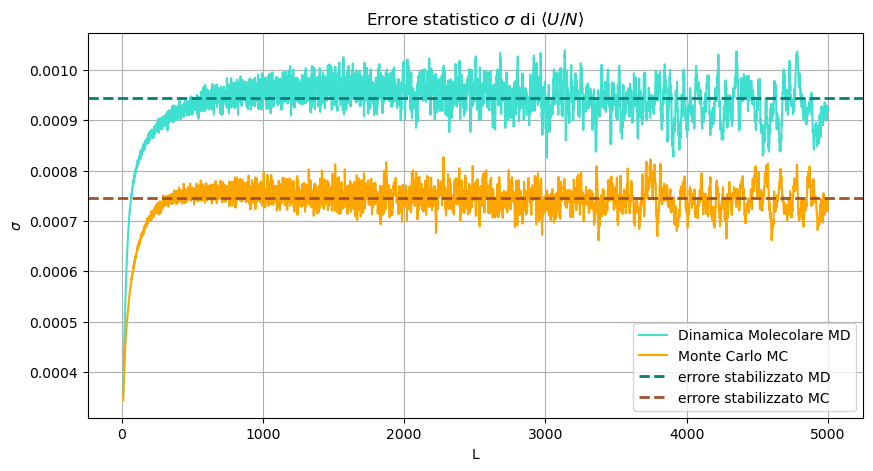

Per MD l'errore è σ = 0.000945
Per MC l'errore è σ = 0.000745


In [3]:
# Calcolo e stampa errore progressivo
import numpy as np
import matplotlib.pyplot as plt

def Prog_Error(x,L):
    N_block=len(x)//L     # numero intero di blocchi da L step che ci stanno dentro x

    if N_block < 2:
        return np.nan     # se ho meno di due blocchi restituisco not a number

    x_eff=x[:N_block*L]                                        # taglia la fine di x per avere un multiplo esatto di L
    matr_blocchi = x_eff.reshape(N_block, L)                   # trasforma x_eff in una matrice con N_block righe e L colonne
    media_blocchi = matr_blocchi.mean(axis=1)                  # calcola la media per ogni blocco (riga), righe = (axis=1)
    err_L = np.std(media_blocchi, ddof=1) / np.sqrt(N_block)   # calcola la deviazione standard della media (ddof=1 indica devstd campionaria)

    return err_L


# ---------------- inizio main ---------------------------------------------------------------------------------------------------------------

L_MIN = 10       # dimensione minima del blocco
L_MAX = 5000     # dimensione massima del blocco
N_LVALUES = 5000  # quanti dati prendere

L_values = np.unique(np.linspace(L_MIN, L_MAX, N_LVALUES).astype(int))  # prende valori equispaziati tra L_MIN e L_MAX


sigma_MD = []
sigma_MC = []
for L in L_values:
    sigma_MD.append(Prog_Error(pot_energy_MD, L))
    sigma_MC.append(Prog_Error(pot_energy_MC, L))
sigma_MD = np.array(sigma_MD)
sigma_MC = np.array(sigma_MC)


errore_medio_MD = np.mean(sigma_MD[1000:])
errore_medio_MC = np.mean(sigma_MC[1000:])

plt.figure(figsize=(10, 5))
plt.plot(L_values, sigma_MD, color='turquoise', label='Dinamica Molecolare MD')
plt.plot(L_values, sigma_MC, color='orange', label='Monte Carlo MC')
plt.axhline(y=errore_medio_MD, color='teal', linestyle='--', linewidth=2, label = 'errore stabilizzato MD')
plt.axhline(y=errore_medio_MC, color='sienna', linestyle='--', linewidth=2, label = 'errore stabilizzato MC')
plt.xlabel("L")
plt.ylabel(rf"$\sigma$")
plt.title(rf"Errore statistico $\sigma$ di $\langle U/N \rangle$ ")
plt.grid()
plt.legend()
plt.show()

print(rf"Per MD l'errore è σ = {errore_medio_MD:.3g}") # tronco a 3 cifre significative
print(rf"Per MC l'errore è σ = {errore_medio_MC:.3g}")

Come si può vedere dal grafico, l'errore statistico segue a pieno l'andamento che ci aspettavamo. Per la Dinamica Molecolare il plateau inizia a essere stabile intorno a $L\sim 1000$, mentre per Monte Carlo già a partire da $L \sim 500$. Questo comportamento può essere spiegato dal fatto che in MD le configurazioni sono legate a quelle precedenti dalla continuità della dinamica newtoniana (implementata con l'algoritmo di Verlet); invece in MC lo spazio delle fasi viene esplorato stocasticamente, rendendo i blocchi statisticamente più indipendenti. È proprio questa maggiore indipendenza statistica a spiegare anche perché l'errore finale risulti più basso nel caso di Monte Carlo rispetto alla Dinamica Molecolare.

## <span style="color:turquoise"> Esercizio 7.3 </span>
In questo esercizio è stato chiesto di implementare la funzione di distribuzione radiale $g(r)$, opportunamente normalizzata, che rappresenta la probabilità di trovare una particella a distanza $r$ rispetto a quanto ci si aspetterebbe per un gas ideale uniforme. Il calcolo è stato effettuato a partire dalla seguente formula:
$$ g(r) = \frac{1}{\rho\, N\, \Delta V (r)} \left \langle \sum \sum^N_{i \neq j =1} \delta \left (|\vec{r}| - |\vec{r_i}-\vec{r_j}| \right ) \right \rangle  \qquad \qquad \text{con} \;\;  \Delta V(r)= \frac{4 \pi}{3} ( (r+dr)^3 - r^3 )$$
dove $\rho$ è la densità numerica del sistema, $N$ è il numero di particelle e $\Delta V(r)$ è il volume del guscio sferico di raggio $r$ e spessore $dr$.

## <span style="color:turquoise"> Esercizio 7.4 </span>
In questo esercizio è stato chiesto di analizzare un sistema di $N=108$ particelle in fase liquida (densità $\rho^\star = 0.8$ e temperatura $T^* = 1.1$) di Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) e di misurare l'energia potenziale per particella $U/N$, la pressione $P$ e la funzione di distribuzione radiale $g(r)$  sia attraverso una simulazione Monte Carlo (MC) nell'ensemble canonico $(N,V,T)$, sia una simulazione di Dinamica Molecolare (MD) nell'ensemble microcanonico $(N, V, E)$.

Per consentire il calcolo della pressione anche nel caso di MC, in cui l'energia cinetica è nulla poichè le velocità non vengono evolute, viene apportata la seguente modifica al codice:

    if(_sim_type == 1){
          _measurement[_index_pressure] = _measurement[_index_pressure] = _rho * _temp + (_ptail*_npart + 48.0*virial/3.0)/_volume;
    } else {
          _measurement[_index_pressure] = _rho*(2.0/3.0)*kenergy_temp + (_ptail*_npart + 48.0*virial/3.0)/_volume;
    }

Poiché la simulazione restituisce i dati in unità di Lennard-Jones, per rappresentare i risultati per l'Argon in unità SI è necessario convertire le grandezze fisiche analizzate tramite le seguenti relazioni, dove con $^*$ sono indicate le grandezze in unità LJ: 
$$U/N= \epsilon\cdot (U/N)^* \qquad \qquad  T= \frac{\epsilon}{k_B}\cdot  T^* \qquad \qquad r=  \sigma \cdot  r^* \qquad \qquad  P= \frac{\epsilon}{\sigma ^3}\cdot  P^*$$


Per entrambe le simulazioni è necessaria una fase di equilibrazione.
- Per MD si osserva che la temperatura diminuisce significativamente, perciò è necessario partire da una configurazione con temperatura maggiore (nel nostro caso si è verificato che la temperatura ottimale corrisponde a $T^*=1.995$), in modo tale che il sistema oscilli attorno alla temperatura desiderata di $T^*=1.1$ (corrispondente a $T=132.0$ K). Come si può vedere dal grafico sottostante a sinistra, la temperatura si stabilizza rapidamente attorno al valore desiderato.
- Per MC, poichè la temperatura è una costante del sistema, verifichiamo che l'energia interna per particella $U/N$ si assesti a oscillare attorno a un valor medio. Come si può vedere dal grafico sottostante a destra, ciò avviene molto rapidamente.

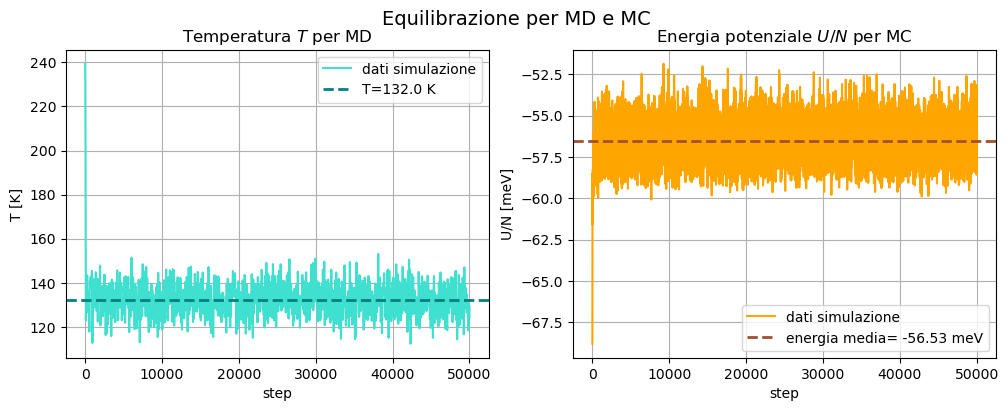

In [7]:
# equilibrazione
import numpy as np
import matplotlib.pyplot as plt

kB = 1.38065e-23           # J/K
m = 39.948 * 1.66054e-27   # kg
sigma = 0.34e-9          # m
eps_over_kB = 120.0       # K
eps = kB * eps_over_kB     # J
eV=1.60218e-19
meV=eV/1000
ps = 1e-12
MPa = 1e6

temp_wanted= 1.1*eps_over_kB

data_temp = np.loadtxt("Esercizio7.3/OUTPUT/temperature_MD_equi.dat", comments='#')
data_pe = np.loadtxt("Esercizio7.3/OUTPUT/potential_energy_MC_equi.dat", comments='#')

temp_time = data_temp * eps_over_kB
penergy_time = data_pe * eps / meV

n_step = np.linspace(1, len(temp_time), len(temp_time))

en_media = np.mean(penergy_time[100:])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Equilibrazione per MD e MC', fontsize=14)

ax1.plot(n_step,temp_time,color='turquoise', label = 'dati simulazione')
ax1.axhline(y=temp_wanted, color='teal', linestyle='--', linewidth=2, label = rf"T={temp_wanted} K")
ax1.set_xlabel("step")
ax1.set_ylabel("T [K]")
ax1.set_title("Temperatura $T$ per MD")
ax1.grid()
ax1.legend()

ax2.plot(n_step,penergy_time,color='orange', label = 'dati simulazione')
ax2.axhline(y=en_media, color='sienna', linestyle='--', linewidth=2, label = f'energia media= {en_media:.4g} meV')
ax2.set_xlabel("step")
ax2.set_ylabel("U/N [meV]")
ax2.set_title("Energia potenziale $U/N$ per MC")
ax2.grid()
ax2.legend()

plt.show()

Come si vede dal seguente grafico le funzioni di distribuzione radiale vengono pressochè identiche per entrambi i metodi. La $g(r)$ presenta due picchi in prossimità di $r_1\sim 350$ pm $\sim \sigma$ e di $r_2\sim 700$ pm $\sim 2 \sigma$ ed è inoltre evidente il comportamento asintotico $g(r) \rightarrow 1$ per $r\rightarrow \infty$.

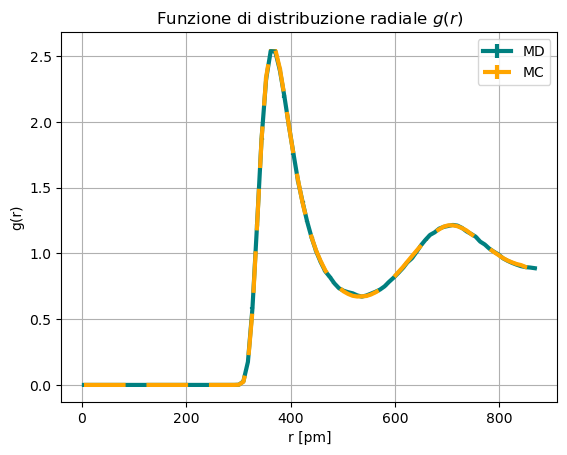

In [5]:
# gofr

import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("Esercizio7.3/OUTPUT/gofr_MD.dat")
raggi_MD = data[:, 0] * sigma / ps
gofr_MD = data[:, 2]
gofr_err_MD = data[:, 3]

dati = np.loadtxt("Esercizio7.3/OUTPUT/gofr_MC.dat")
raggi_MC = dati[:, 0] * sigma / ps
gofr_MC = dati[:, 2]
gofr_err_MC = dati[:, 3]

plt.figure()
plt.errorbar(raggi_MD,gofr_MD, yerr=gofr_err_MD, color='teal', lw=3, label='MD')
plt.errorbar(raggi_MC,gofr_MC, yerr=gofr_err_MC, color='orange', ls='--',  dashes=(10, 5), lw=3, label='MC')
plt.xlabel("r [pm]")
plt.ylabel("g(r)")
plt.title("Funzione di distribuzione radiale $g(r)$")
plt.legend()

plt.grid()
plt.show()

Per quanto riguarda la pressione $P$ e l'energia potenziale per particella $U/N$, nel grafico sottostante si osserva che i valori medi a cui convergono i due metodi non sono compatibili statisticamente. Questo risultato può essere spiegato considerando che il Monte Carlo $(N,V,T)$ e la Dinamica Molecolare $(N,V,E)$ agiscono in due ensamble differenti: in MD si conserva l'energia totale mentre la temperaura fluttua, invece in MC è la temperatura a conservarsi. Sono proprio queste fluttuazioni di temperatura in MD a determinare valori medi sistematicamente più alti rispetto a quelli ottenuti con MC.

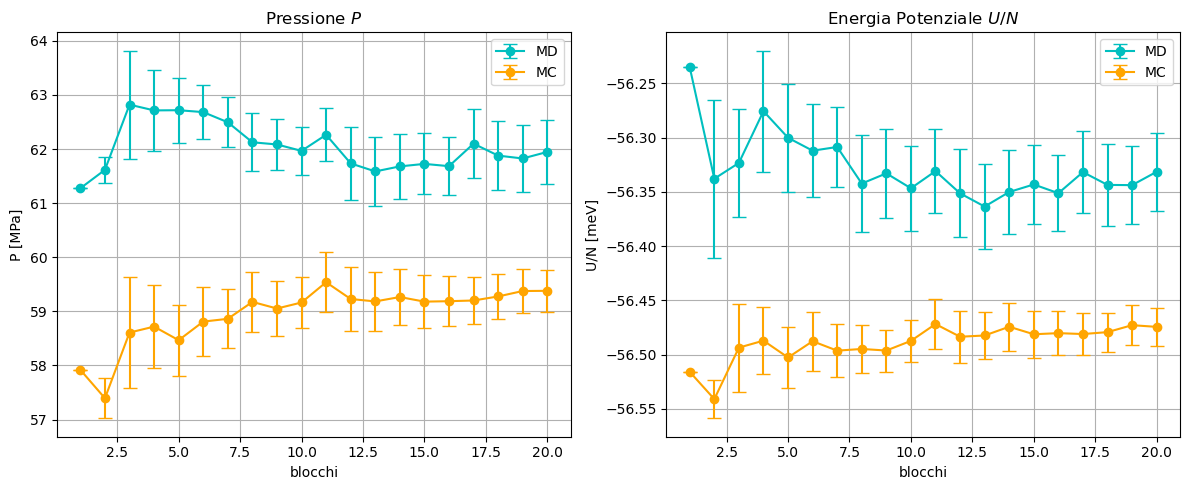

In [6]:
# pressione e U/N

import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("Esercizio7.3/OUTPUT/pressure_MD.dat")
block_MD = data[:, 0] 
press_MD = data[:, 2] * eps / (sigma*sigma*sigma) /MPa
press_err_MD = data[:, 3] * eps / (sigma*sigma*sigma) /MPa

data = np.loadtxt("Esercizio7.3/OUTPUT/pressure_MC.dat")
block_MC = data[:, 0] 
press_MC = data[:, 2] * eps / (sigma*sigma*sigma) /MPa
press_err_MC = data[:, 3] * eps / (sigma*sigma*sigma) /MPa

data = np.loadtxt("Esercizio7.3/OUTPUT/potential_energy_MD.dat")
block_MD = data[:, 0]
energy_MD = data[:, 2] * eps / meV
energy_err_MD = data[:, 3] * eps / meV

data = np.loadtxt("Esercizio7.3/OUTPUT/potential_energy_MC.dat")
block_MC = data[:, 0]
energy_MC = data[:, 2] * eps / meV
energy_err_MC = data[:, 3] * eps / meV



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(block_MD, press_MD, yerr=press_err_MD, color='c', fmt='o-',capsize=5, label='MD')
ax1.errorbar(block_MC, press_MC, yerr=press_err_MC, color='orange', fmt='o-',capsize=5, label='MC')
ax1.set_xlabel("blocchi")
ax1.set_ylabel("P [MPa]")
ax1.set_title("Pressione $P$")
ax1.legend()
ax1.grid()

ax2.errorbar(block_MD, energy_MD, yerr=energy_err_MD, color='c', capsize=5, fmt='o-', label='MD')
ax2.errorbar(block_MC, energy_MC, yerr=energy_err_MC, color='orange', capsize=5, fmt='o-', label="MC")
ax2.set_xlabel("blocchi")
ax2.set_ylabel("U/N [meV]")
ax2.set_title("Energia Potenziale $U/N$")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()